# IA PARA CIENCIA DE DATOS

## Contenido

1. Cargar librerías
1. Leer archivo y procesar datos
1. ML methods
1. Fine-tuning
1. Model Comparison

## 1. Cargar librerías

In [23]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np # to use numpy arrays instead of lists
import pandas as pd # DataFrame (table)

# Matplotlib and seaborn for charting
import matplotlib.pyplot as plt # to plot
import seaborn as sns # to plot

np.random.seed(0)

In [24]:
# Sklearn processing modules
from sklearn import preprocessing # to normalize data
from sklearn.model_selection import train_test_split

# Sklearn clustering algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import MeanShift

# Sklearn to find the best hyperparameters
from sklearn.model_selection import GridSearchCV

In [25]:
# Sklearn clustering model evaluation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [26]:
# Wilcoxon signed-rank test
from scipy.stats import wilcoxon
# α = 0.05
# Valor p ≤ α: La diferencia entre las medianas es significativamente diferente (Rechaza H0) 
# Valor p > α: La diferencia entre las medianas no es significativamente diferente (No puede rechazar H0) 

In [27]:
# Load built-in sample data set
from sklearn.datasets import load_iris

## 2. Cargar y procesar datos

### 2.1 Cargar datos

In [28]:
# we load the iris dataset
# the dataset load as an array 
iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df["Iris_type"]=iris_data.target
print(iris_df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     Iris_type  
0         

### 2.2 Procesar datos

In [29]:
def procesarDatos(dataSet=0):
    """
    Normalize and smooth data
    """
    dataSet = dataSet.fillna(method='ffill')

    # fit the scaler
    scaler = preprocessing.MinMaxScaler()
    scaler.fit(dataSet)

    # Transform the data using the fitted scaler
    np_dataSet = scaler.transform(dataSet)

    # Convert the numpy array back to a DataFrame
    dataSet = pd.DataFrame(np_dataSet, columns=dataSet.columns, index=dataSet.index)

    return dataSet

In [30]:
datosProcesados = procesarDatos(iris_df)
datosProcesados['Iris_type'] = iris_df['Iris_type']
print(datosProcesados)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0             0.222222          0.625000           0.067797          0.041667   
1             0.166667          0.416667           0.067797          0.041667   
2             0.111111          0.500000           0.050847          0.041667   
3             0.083333          0.458333           0.084746          0.041667   
4             0.194444          0.666667           0.067797          0.041667   
..                 ...               ...                ...               ...   
145           0.666667          0.416667           0.711864          0.916667   
146           0.555556          0.208333           0.677966          0.750000   
147           0.611111          0.416667           0.711864          0.791667   
148           0.527778          0.583333           0.745763          0.916667   
149           0.444444          0.416667           0.694915          0.708333   

     Iris_type  
0         

### 2.3 Split Data

In [31]:
# Split data into train and test sets
train_size = 0.75
test_size = 1 - train_size
trainSet, testSet = train_test_split(datosProcesados, test_size=test_size, random_state=0)

print("Train set")
print(trainSet.head())
print()
print('trainSet shape: ', trainSet.shape)
print()

print("Test set")
print(testSet.head())
print()
print('testSet shape: ', testSet.shape)

Train set
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
61            0.444444          0.416667           0.542373          0.583333   
92            0.416667          0.250000           0.508475          0.458333   
112           0.694444          0.416667           0.762712          0.833333   
2             0.111111          0.500000           0.050847          0.041667   
141           0.722222          0.458333           0.694915          0.916667   

     Iris_type  
61           1  
92           1  
112          2  
2            0  
141          2  

trainSet shape:  (112, 5)

Test set
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
114           0.416667          0.333333           0.694915          0.958333   
62            0.472222          0.083333           0.508475          0.375000   
33            0.333333          0.916667           0.067797          0.041667   
107           0.833333          0.375000

## 3. ML methods

### 3.1 Método de codo

In [32]:
# Get feature column names (all except the target column)
columnsNames = datosProcesados.columns[:-1]
print(columnsNames)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


In [33]:
# Find the inertia for diferent k values
inertias = []
k_values = range(1,6)

for k in k_values:
    kmeans = KMeans(n_clusters= k, random_state=0)
    kmeans.fit(trainSet[columnsNames])
    inertias.append(kmeans.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

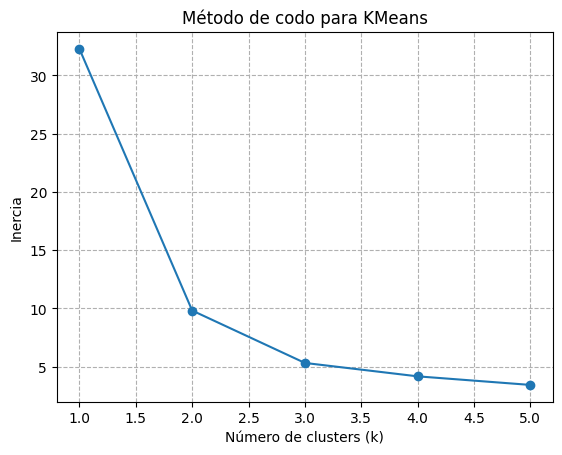

In [34]:
plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método de codo para KMeans')
plt.grid(linestyle='dashed')
plt.show

### 3.1 Entrenamiento

In [35]:
# DataFrame to store model performance metrics
methods = ['KMeans', 'MiniBatchKMeans', 'MeanShift']
performanceHeaders = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
trainModelMetrics = pd.DataFrame(columns=performanceHeaders, index=methods)
testModelMetrics = pd.DataFrame(columns=performanceHeaders, index=methods)
print(trainModelMetrics)
print()
print(testModelMetrics)

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans                 NaN               NaN            NaN
MiniBatchKMeans        NaN               NaN            NaN
MeanShift              NaN               NaN            NaN

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans                 NaN               NaN            NaN
MiniBatchKMeans        NaN               NaN            NaN
MeanShift              NaN               NaN            NaN


In [36]:
def compareMethod(position, columnsNames, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel):
    """
    Compare clustering methods using evaluation metrics
    """
    # Train set metrics
    trainModelMetrics.iloc[position, 0] = silhouette_score(trainModel[columnsNames], trainModel[modelName])
    trainModelMetrics.iloc[position, 1] = calinski_harabasz_score(trainModel[columnsNames], trainModel[modelName])
    trainModelMetrics.iloc[position, 2] = davies_bouldin_score(trainModel[columnsNames], trainModel[modelName])


    # Test set metrics
    testModelMetrics.iloc[position, 0] = silhouette_score(testModel[columnsNames], testModel[modelName])
    testModelMetrics.iloc[position, 1] = calinski_harabasz_score(testModel[columnsNames], testModel[modelName])
    testModelMetrics.iloc[position, 2] = davies_bouldin_score(testModel[columnsNames], testModel[modelName])

    return trainModelMetrics, testModelMetrics


In [37]:
# Perform KMeans clustering
modelName = 'KMeansCluster'
position = 0
KMestimator = KMeans(n_clusters=3, random_state=0)
KMestimator.fit(trainSet[columnsNames])
# we obtain the cluster labels from the training set
trainSet[modelName]=KMestimator.labels_
print(trainSet.iloc[:,4:].head())
print()

# we obtain the cluster labels for the test set
testSet[modelName] = KMestimator.predict(testSet[columnsNames])
print(testSet.iloc[:,4:].head())
print()

trainModelMetrics, testModelMetrics = compareMethod(position, columnsNames, modelName, trainModelMetrics, testModelMetrics, trainSet, testSet)

print(trainModelMetrics)
print()
print(testModelMetrics)

     Iris_type  KMeansCluster
61           1              2
92           1              2
112          2              1
2            0              0
141          2              1

     Iris_type  KMeansCluster
114          2              1
62           1              2
33           0              0
107          2              1
7            0              0

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans            0.512315        276.688255       0.735941
MiniBatchKMeans        NaN               NaN            NaN
MeanShift              NaN               NaN            NaN

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans            0.480757         85.412556        0.80732
MiniBatchKMeans        NaN               NaN            NaN
MeanShift              NaN               NaN            NaN


In [38]:
# Perform MiniBatchKMeans clustering
modelName = 'MiniBatchKMeansCluster'
position = 1
MBKestimator = MiniBatchKMeans(n_clusters=3, random_state=0)
MBKestimator.fit(trainSet[columnsNames])
# we obtain the cluster labels from the training set
trainSet[modelName]=MBKestimator.labels_
print(trainSet.iloc[:,4:].head())
print()

# we obtain the cluster labels for the test set
testSet[modelName] = MBKestimator.predict(testSet[columnsNames])
print(testSet.iloc[:,4:].head())
print()

trainModelMetrics, testModelMetrics = compareMethod(position, columnsNames, modelName, trainModelMetrics, testModelMetrics, trainSet, testSet)

print(trainModelMetrics)
print()
print(testModelMetrics)

     Iris_type  KMeansCluster  MiniBatchKMeansCluster
61           1              2                       0
92           1              2                       0
112          2              1                       2
2            0              0                       1
141          2              1                       2

     Iris_type  KMeansCluster  MiniBatchKMeansCluster
114          2              1                       2
62           1              2                       0
33           0              0                       1
107          2              1                       2
7            0              0                       1

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans            0.512315        276.688255       0.735941
MiniBatchKMeans   0.512315        276.688255       0.735941
MeanShift              NaN               NaN            NaN

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans            0.480757         85.412556     

In [39]:
# Perform MeanShift clustering
modelName = 'MeanShiftCluster'
position = 2
MSEstimator = MeanShift()
MSEstimator.fit(trainSet[columnsNames])
# we obtain the cluster labels from the training set
trainSet[modelName]=MSEstimator.labels_
print(trainSet.iloc[:,4:].head())
print()

# we obtain the cluster labels for the test set
testSet[modelName] = MSEstimator.predict(testSet[columnsNames])
print(testSet.iloc[:,4:].head())
print()

trainModelMetrics, testModelMetrics = compareMethod(position, columnsNames, modelName, trainModelMetrics, testModelMetrics, trainSet, testSet)

print(trainModelMetrics)
print()
print(testModelMetrics)

     Iris_type  KMeansCluster  MiniBatchKMeansCluster  MeanShiftCluster
61           1              2                       0                 0
92           1              2                       0                 0
112          2              1                       2                 0
2            0              0                       1                 1
141          2              1                       2                 0

     Iris_type  KMeansCluster  MiniBatchKMeansCluster  MeanShiftCluster
114          2              1                       2                 0
62           1              2                       0                 0
33           0              0                       1                 1
107          2              1                       2                 0
7            0              0                       1                 1

                Silhouette Calinski-Harabasz Davies-Bouldin
KMeans            0.512315        276.688255       0.735941
MiniBatchKMean

## 6. Model Comparison

In [40]:
def compareModels(dataSet):
    columnsNames = dataSet.columns
    size = len(columnsNames)

    for i in range(size):
        print("Wilcoxon signed-rank test for " + columnsNames[i])
        print()

        # Wilcoxon signed-rank test
        print("Methods without fine tuning")
        print(dataSet.iloc[:,i])
        print()
        statistic, p_value = wilcoxon(dataSet.iloc[:,i].dropna().values)
        print("Wilcoxon signed-rank test statistic:", statistic)
        print("p-value:", p_value)
        print()

        plt.figure()
        sns.barplot(x=dataSet.index, y=dataSet.iloc[:,i].astype(float))
        plt.title(f'Model {columnsNames[i]} Comparison', fontweight='bold')
        plt.xlabel('Models')
        plt.show()


Wilcoxon signed-rank test for Silhouette

Methods without fine tuning
KMeans             0.480757
MiniBatchKMeans    0.449024
MeanShift          0.669101
Name: Silhouette, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.25



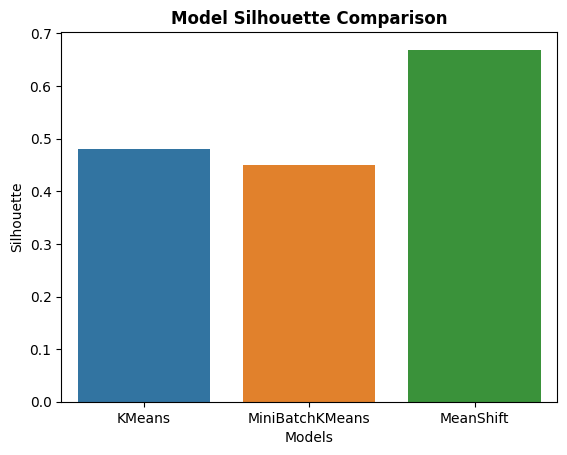

Wilcoxon signed-rank test for Calinski-Harabasz

Methods without fine tuning
KMeans              85.412556
MiniBatchKMeans     83.444853
MeanShift          115.994025
Name: Calinski-Harabasz, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.25



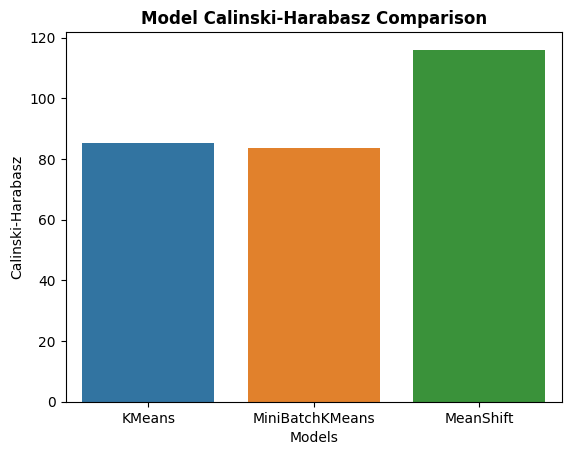

Wilcoxon signed-rank test for Davies-Bouldin

Methods without fine tuning
KMeans              0.80732
MiniBatchKMeans    0.902597
MeanShift           0.43141
Name: Davies-Bouldin, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.25



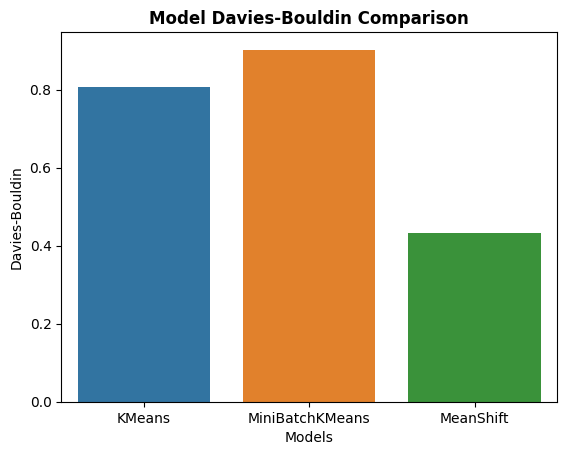

In [21]:
compareModels(testModelMetrics)